In [64]:
!pip install pykalman

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import yfinance as yf
from pykalman import KalmanFilter

In [66]:
df = yf.download('^NSEI', start='2016-01-01', end='2026-01-01',multi_level_index=False,auto_adjust=False)
df['price_returns'] = np.log(df['Adj Close']/df['Adj Close'].shift(1))

[*********************100%***********************]  1 of 1 completed


In [67]:
def calculate_obv(df):
    # df must contain 'Adj Close' and 'Volume'
    obv = [0]
    for i in range(1, len(df)):
        if df['Adj Close'].iloc[i] > df['Adj Close'].iloc[i-1]:
            obv.append(obv[-1] + df['Volume'].iloc[i])
        elif df['Adj Close'].iloc[i] < df['Adj Close'].iloc[i-1]:
            obv.append(obv[-1] - df['Volume'].iloc[i])
        else:
            obv.append(obv[-1])

    df['OBV'] = obv
    return df

def apply_kalman_filter(df, column='Adj Close'):
    kf = KalmanFilter(
        transition_matrices = [1],
        observation_matrices = [1],
        initial_state_mean = df[column].iloc[0],
        initial_state_covariance = 1,
        observation_covariance = 1,
        transition_covariance = 0.01  # Smaller values = smoother line
    )

    # Use the filter on the data
    state_means, _ = kf.filter(df[column].values)
    df['Kalman_Price'] = state_means
    return df

In [69]:
calculate_obv(df)
df = apply_kalman_filter(df)
df['kalman_returns'] = np.log(df.Kalman_Price/df.Kalman_Price.shift(1))
window = 20
df['obv_rolling_mu'] = df['OBV'].rolling(window).mean()
df['obv_rolling_std'] = df['OBV'].rolling(window).std()
df['obv'] = (df['OBV'] - df['obv_rolling_mu']) / df['obv_rolling_std']
df = df[['kalman_returns','price_returns','obv']]
df.dropna(axis=0, how='any', inplace=True)

/tmp/ipykernel_8548/1556770323.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(axis=0, how='any', inplace=True)


In [77]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.tsa.ar_model import AutoReg  # Corrected path and casing
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.graphics.tsaplots as sgt  # For ACF/PACF plots
print("ADF test of columns --> Price returns, Kalman returns, OBV")


result = adfuller(df['price_returns'])
print(f"price returns ADF Statistic: {result[0]}")
print(f"price returns p-value: {result[1]}")
print(f"price returns Critical Values: {result[2]}")

result1 = adfuller(df['kalman_returns'])
print(f"Kalman ADF Statistic: {result1[0]}")
print(f"kalman p-value: {result1[1]}")  a
print(f"kalman Critical Values: {result1[2]}")

result2 = adfuller(df['obv'])
print(f"obv ADF Statistic: {result2[0]}")
print(f"obv p-value: {result2[1]}")
print(f"obv Critical Values: {result2[2]}")


ADF test of columns --> Price returns, Kalman returns, OBV
price returns ADF Statistic: -13.624587631713117
price returns p-value: 1.7700926809376795e-25
price returns Critical Values: 11
Kalman ADF Statistic: -8.800698511810225
kalman p-value: 2.1162166397367385e-14
kalman Critical Values: 12
obv ADF Statistic: -11.35677033394599
obv p-value: 9.691368454565486e-21
obv Critical Values: 3


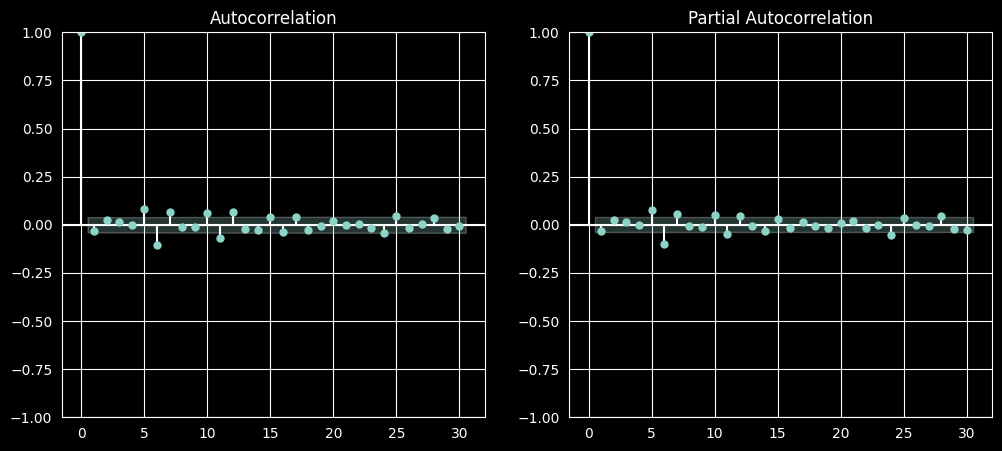

In [79]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = df['price_returns'].dropna()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(series, lags=30, ax=plt.gca())

plt.subplot(1,2,2)
plot_pacf(series, lags=30, ax=plt.gca())

plt.show()

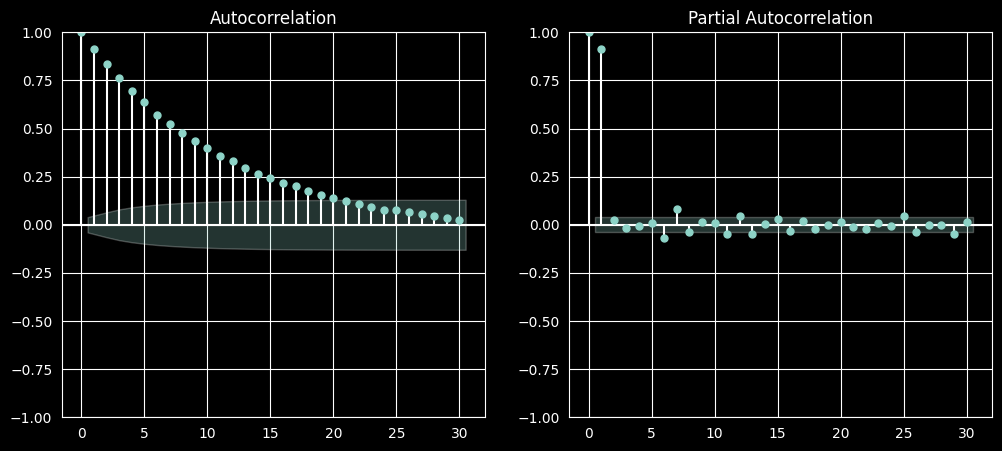

In [80]:
series = df['kalman_returns'].dropna()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(series, lags=30, ax=plt.gca())

plt.subplot(1,2,2)
plot_pacf(series, lags=30, ax=plt.gca())

plt.show()

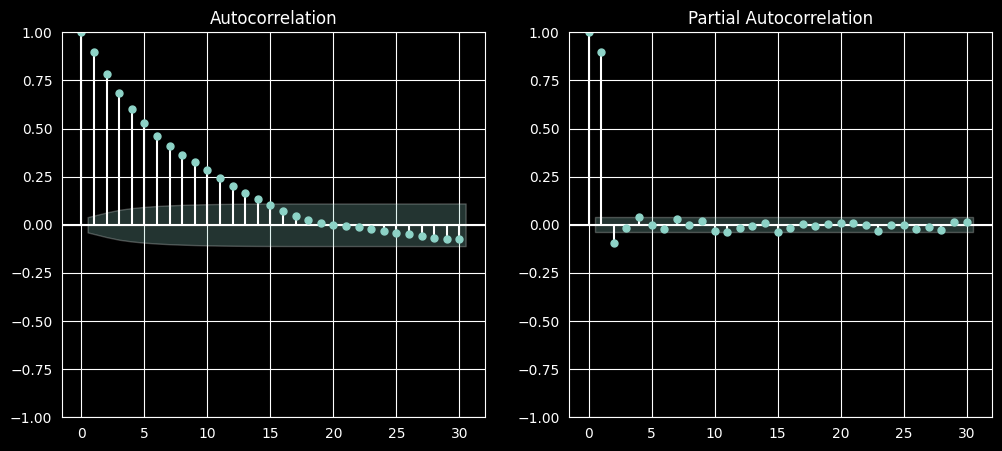

In [81]:
series = df['obv'].dropna()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(series, lags=30, ax=plt.gca())

plt.subplot(1,2,2)
plot_pacf(series, lags=30, ax=plt.gca())

plt.show()